# Sentinel-3 OLCI NDVI with AerEO

This chapter combines the Sentinel-3 OLCI pipeline with an NDVI preprocessor. It demonstrates how AerEO’s composable config lets you reuse an entire sensor pipeline and swap only the product calculation.


In [ ]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[swath,viz]" aereo-read-satpy

## Environment setup

The first cell installs AerEO and the plugins needed for reading and reprojecting Sentinel-3 swath data. On Binder, where these are pre-installed, pip will skip the download.


In [ ]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel3.yaml",
    "config/job_sentinel3.yaml",
)
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel3-ndvi.yaml",
    "config/job_sentinel3-ndvi.yaml",
)

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/chocon.geojson",
    "config/aoi/chocon.geojson",
)

## NASA Earthdata authentication

NASA-hosted Sentinel-3 data requires a valid `~/.netrc`. See the earlier VIIRS chapter for setup instructions.


### NASA Earthdata authentication

The NASA notebooks need a valid `~/.netrc` file. Run this cell once in Colab to create it from your credentials:

```python
import os
from getpass import getpass

# Get Earthdata credentials from the user
earthdata_username = getpass("Earthdata username: ")
earthdata_password = getpass("Earthdata password: ")

# Define the path for the .netrc file in the user's home directory
netrc_path = os.path.expanduser("~/.netrc")

# Create the .netrc file with the provided credentials
with open(netrc_path, "w") as f:
    f.write("machine urs.earthdata.nasa.gov login {username} password {password}\n".format(
        username=earthdata_username,
        password=earthdata_password
    ))

# Set permissions for the .netrc file to be readable only by the owner
os.chmod(netrc_path, 0o600)

print(f"Successfully created {netrc_path} for Earthdata authentication.")
```


## Config used in this notebook

This notebook loads the job from `examples/config/job_sentinel3-ndvi.yaml`. It extends `job_sentinel3` and adds an `NDVI` preprocess stage:

```yaml
defaults:
  - job_sentinel3
  - _self_

name: sentinel3_ndvi
preprocess:
  - _target_: aereo.builtins.ndvi
    _partial_: true
    ndvi_nir_band: Oa17
    ndvi_red_band: Oa08
```


## Config: extending the OLCI job with NDVI

`job_sentinel3-ndvi.yaml` inherits from `job_sentinel3.yaml` and adds the NDVI preprocessor:

```yaml
defaults:
  - job_sentinel3
  - _self_

name: sentinel3_ndvi
preprocess:
  - _target_: aereo.builtins.ndvi
    _partial_: true
    ndvi_nir_band: Oa17
    ndvi_red_band: Oa08
```

Note that the band names match the OLCI band naming convention (`Oa08`, `Oa17`) rather than Sentinel-2’s `red`/`nir`. Hydra composition means the rest of the OLCI config is inherited unchanged.


In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel3-ndvi",
)

## Loading the job

`load_from_config` merges the base OLCI config with the NDVI override, producing a job whose pipeline is: search OLCI → read with Satpy → compute NDVI → reproject swath → write GeoTIFF.


In [2]:
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)
len(tasks)

2026-07-08 15:06:54 [info     ] search_called                  provider=search_earthaccess


/root/repos/aereo/.venv/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/root/repos/aereo/components/aereo/builtins/search.py:324: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  size_mb = g.size()


2026-07-08 15:06:59 [info     ] build_tasks_start              assets=3 builder=build_grouped_tasks


/root/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


3

## Search, build, and execute

The workflow is the same as the base Sentinel-3 chapter. Each task now emits an NDVI GeoTIFF.


In [3]:
# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=2, use_threads=False, cache=TaskResultCache())

In [ ]:
# Extract!
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts)} artifacts")

(<Figure size 2000x1981.62 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


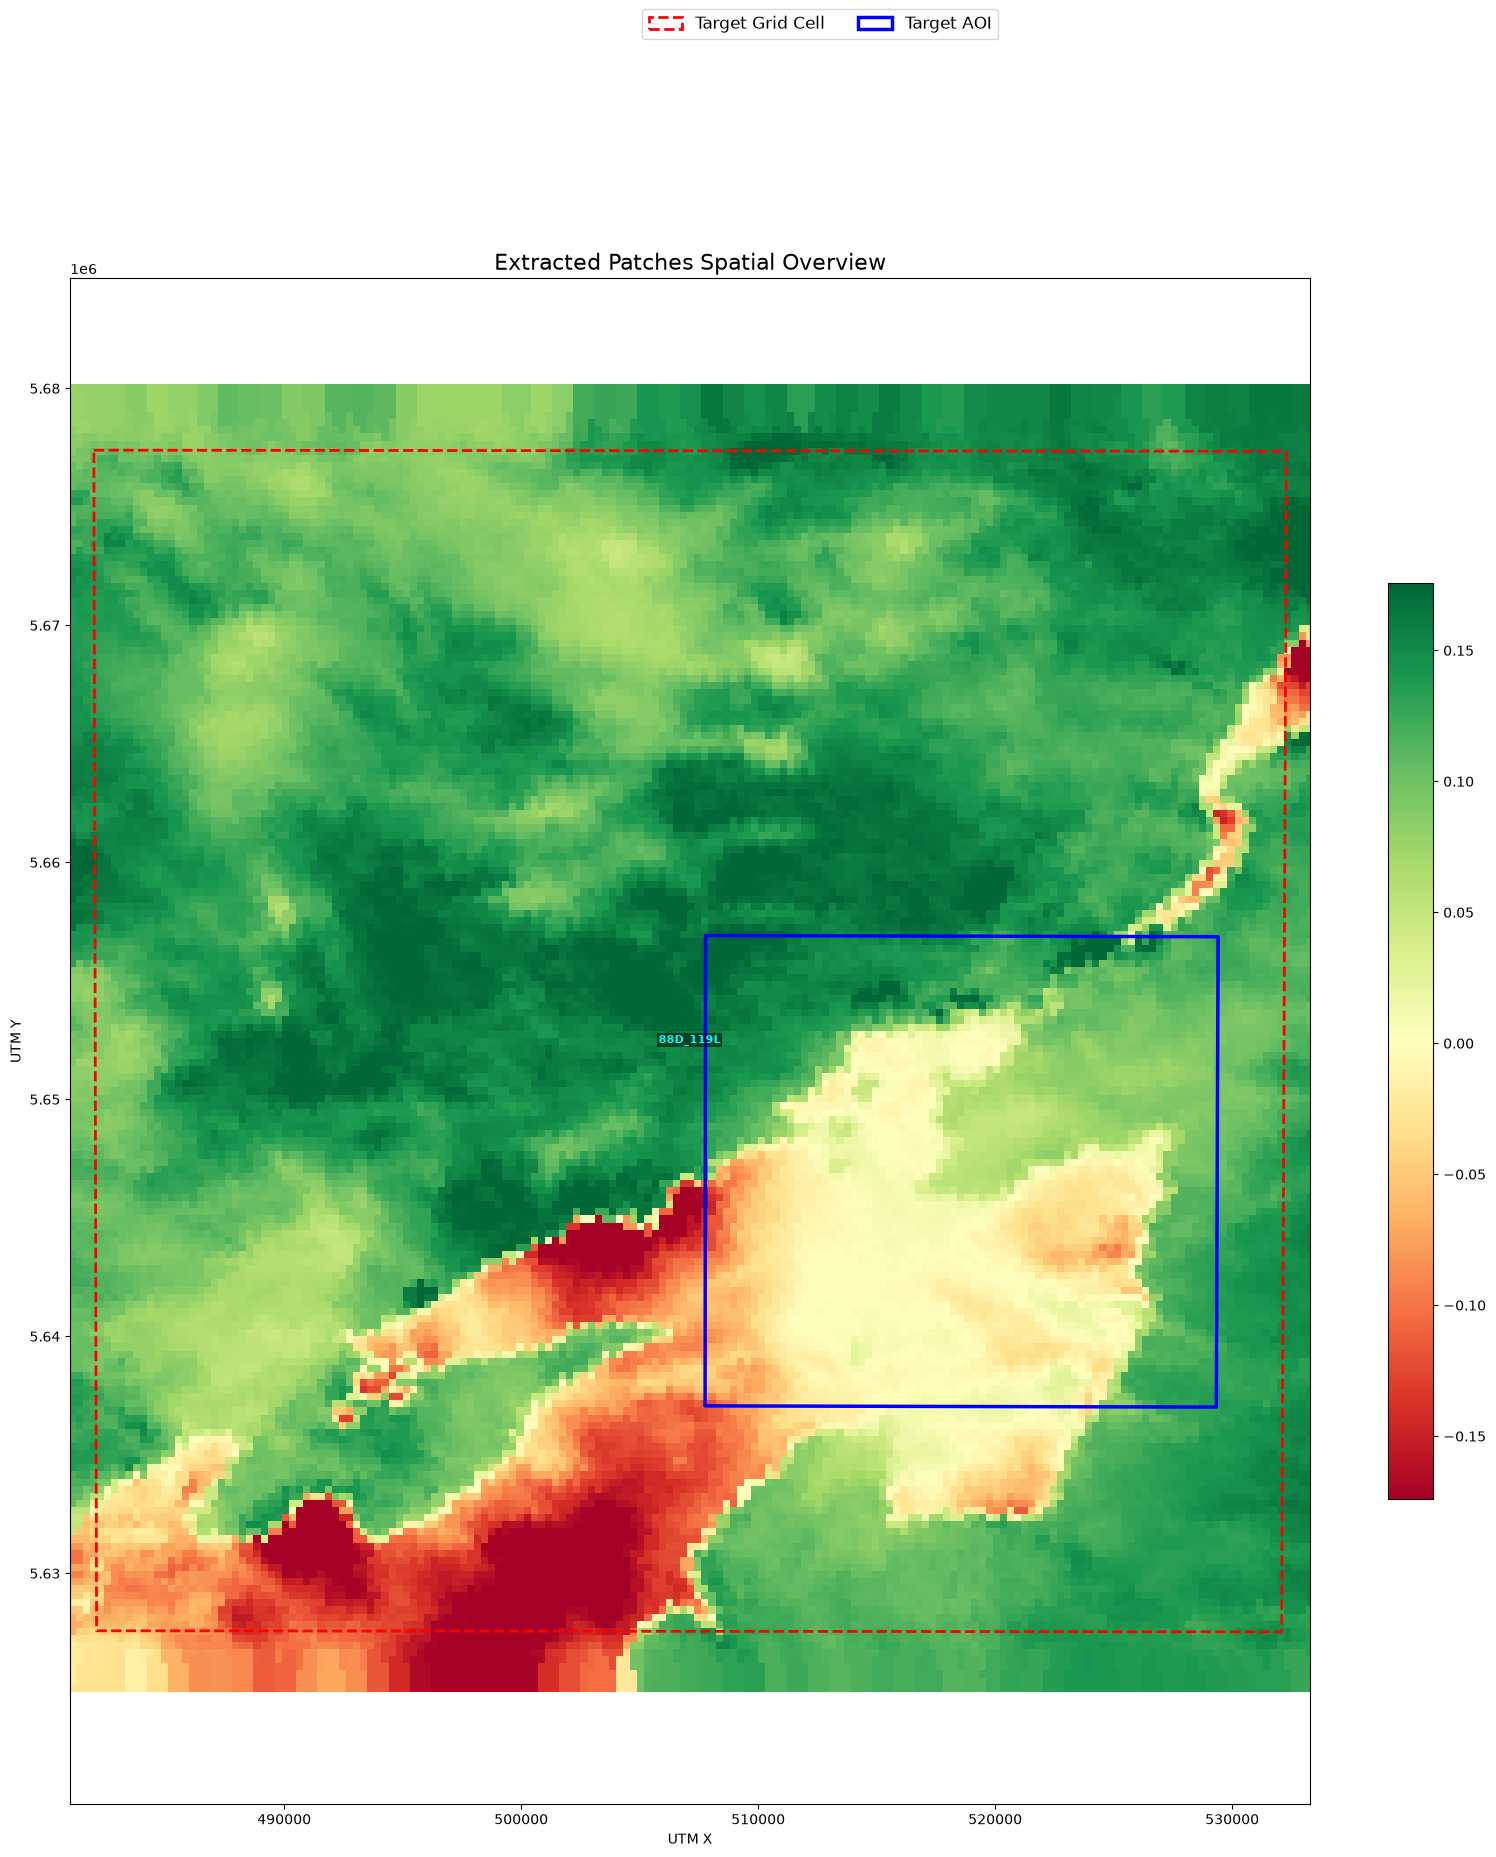

In [5]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(
    artifacts,
    ds_factor=1,
    cmap="RdYlGn",
    stretch="percentile",
    aoi=job.target_aoi,
    aoi_edgecolor="blue",
)

## Visualizing NDVI from OLCI

OLCI’s 300 m resolution gives a coarser view than Sentinel-2, but the swath width is much larger, making it well suited for regional vegetation monitoring.
